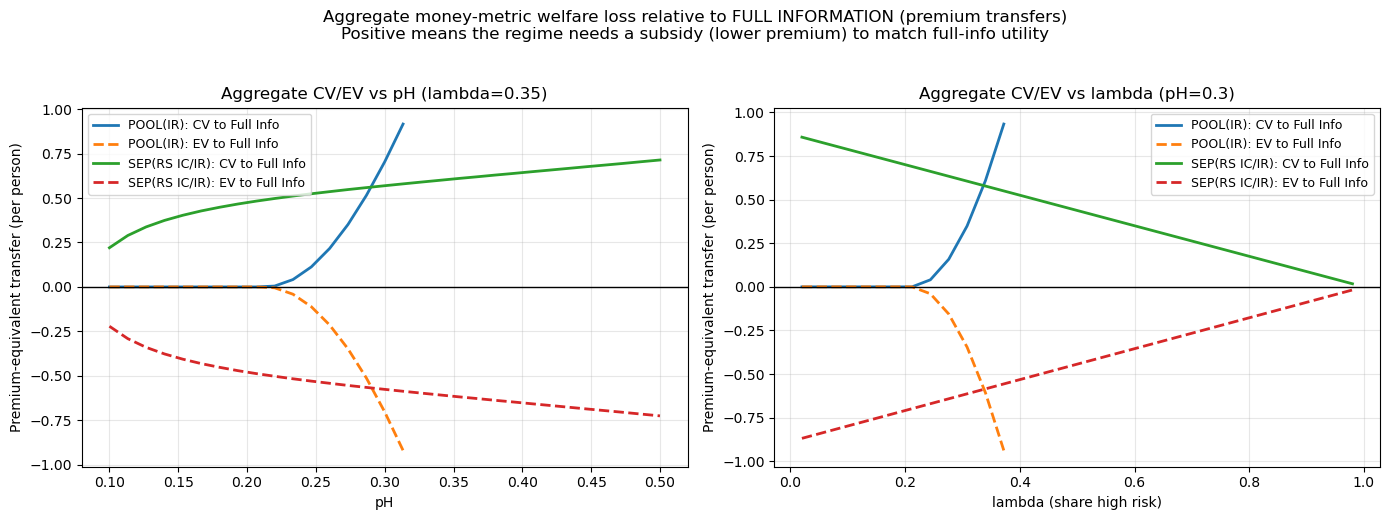

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

# =========================
# PARAMETERS
# =========================
W     = 100.0
Lloss = 40.0
pL    = 0.08
gamma = 2.0

lam_fixed = 0.35   # sweep pH holding lambda fixed
pH_fixed  = 0.30   # sweep lambda holding pH fixed

# =========================
# MODEL
# =========================
def u(c, gamma):
    c = np.maximum(c, 1e-12)
    if abs(gamma - 1.0) < 1e-12:
        return np.log(c)
    return (c ** (1 - gamma)) / (1 - gamma)

def EU(W, Lloss, p, q, pi, gamma):
    cH = W - pi
    cS = W - pi - (1 - q) * Lloss
    return (1 - p) * u(cH, gamma) + p * u(cS, gamma)

def EU0(W, Lloss, p, gamma):
    return (1 - p) * u(W, gamma) + p * u(W - Lloss, gamma)

def cost(Lloss, p, q):
    return p * q * Lloss  # actuarially fair premium

def fullinfo_contract(Lloss, p):
    return {"q": 1.0, "pi": cost(Lloss, p, 1.0)}

# =========================
# POOL(IR): one contract priced at pbar, IR for both types
# =========================
def pooling_opt(W, Lloss, pL, pH, lam, gamma, require_IR=True):
    pbar = lam * pH + (1 - lam) * pL
    EU0L, EU0H = EU0(W, Lloss, pL, gamma), EU0(W, Lloss, pH, gamma)

    def objective(q):
        q = np.clip(q, 0.0, 1.0)
        pi = cost(Lloss, pbar, q)
        EUL = EU(W, Lloss, pL, q, pi, gamma)
        EUH = EU(W, Lloss, pH, q, pi, gamma)
        if require_IR and (EUL < EU0L or EUH < EU0H):
            return 1e9
        return -((1 - lam) * EUL + lam * EUH)

    res = minimize_scalar(objective, bounds=(0.0, 1.0), method="bounded")
    if not res.success:
        return None

    q = float(res.x)
    pi = cost(Lloss, pbar, q)

    if require_IR:
        if EU(W, Lloss, pL, q, pi, gamma) < EU0L - 1e-10: return None
        if EU(W, Lloss, pH, q, pi, gamma) < EU0H - 1e-10: return None

    return {"q": q, "pi": pi, "pbar": pbar}

# =========================
# SEP(RS): competitive-style separating (ROBUST GRID VERSION)
# - H: qH=1, piH=pH*L
# - L: choose qL (priced at pL) to max L utility subject to:
#      IR_L and IC_H
# =========================
def RS_separating_opt_grid(W, Lloss, pL, pH, gamma, grid_n=5001):
    qH = 1.0
    piH = cost(Lloss, pH, qH)
    EUH_at_H = EU(W, Lloss, pH, qH, piH, gamma)
    EU0L = EU0(W, Lloss, pL, gamma)

    qs = np.linspace(0.0, 1.0, grid_n)

    best = None
    for qL in qs:
        piL = cost(Lloss, pL, qL)

        IR_L = EU(W, Lloss, pL, qL, piL, gamma) >= EU0L - 1e-12
        IC_H = EU(W, Lloss, pH, qL, piL, gamma) <= EUH_at_H + 1e-12
        if not (IR_L and IC_H):
            continue

        val = EU(W, Lloss, pL, qL, piL, gamma)
        if best is None or val > best["EUL"]:
            best = {"qL": qL, "piL": piL, "EUL": val}

    if best is None:
        return None

    return {"qL": best["qL"], "piL": best["piL"], "qH": qH, "piH": piH}

# =========================
# Money-metric welfare: premium-based CV/EV
# new premium = pi - T, T>0 is subsidy
# =========================
def feasible_T_bounds_premium(W, Lloss, q, pi):
    lower = pi - (W - (1 - q) * Lloss) + 1e-8
    upper = pi + W
    return lower, upper

def premium_transfer_to_match(W, Lloss, p, gamma, contract_from, target_EU):
    q, pi = contract_from["q"], contract_from["pi"]
    Tmin, Tmax = feasible_T_bounds_premium(W, Lloss, q, pi)

    def f(T):
        return EU(W, Lloss, p, q, pi - T, gamma) - target_EU

    fmin, fmax = f(Tmin), f(Tmax)
    if np.isnan(fmin) or np.isnan(fmax) or fmin * fmax > 0:
        return np.nan
    return brentq(f, Tmin, Tmax, maxiter=500)

def CV_premium(W, Lloss, p, gamma, baseline_contract, policy_contract):
    target = EU(W, Lloss, p, baseline_contract["q"], baseline_contract["pi"], gamma)
    return premium_transfer_to_match(W, Lloss, p, gamma, policy_contract, target)

def EV_premium(W, Lloss, p, gamma, baseline_contract, policy_contract):
    target = EU(W, Lloss, p, policy_contract["q"], policy_contract["pi"], gamma)
    return premium_transfer_to_match(W, Lloss, p, gamma, baseline_contract, target)

# =========================
# Aggregate CV/EV relative to full info
# =========================
def agg_CV_EV_to_fullinfo(pH, lam, regime, rs_grid_n=5001):
    FI_L = fullinfo_contract(Lloss, pL)
    FI_H = fullinfo_contract(Lloss, pH)

    if regime == "POOL(IR)":
        pool = pooling_opt(W, Lloss, pL, pH, lam, gamma, require_IR=True)
        if pool is None: return None
        reg_L = {"q": pool["q"], "pi": pool["pi"]}
        reg_H = {"q": pool["q"], "pi": pool["pi"]}

    elif regime == "SEP(RS IC/IR)":
        rs = RS_separating_opt_grid(W, Lloss, pL, pH, gamma, grid_n=rs_grid_n)
        if rs is None: return None
        reg_L = {"q": rs["qL"], "pi": rs["piL"]}
        reg_H = {"q": rs["qH"], "pi": rs["piH"]}

    else:
        raise ValueError("Unknown regime")

    CV_L = CV_premium(W, Lloss, pL, gamma, FI_L, reg_L)
    EV_L = EV_premium(W, Lloss, pL, gamma, FI_L, reg_L)
    CV_H = CV_premium(W, Lloss, pH, gamma, FI_H, reg_H)
    EV_H = EV_premium(W, Lloss, pH, gamma, FI_H, reg_H)

    return {
        "CV_agg": (1 - lam) * CV_L + lam * CV_H,
        "EV_agg": (1 - lam) * EV_L + lam * EV_H
    }

# =========================
# PLOT: aggregate CV/EV (only) for POOL(IR) vs SEP(RS IC/IR)
# =========================
def plot_aggregate_CV_EV_pool_vs_RS(rs_grid_n=5001):
    pH_grid  = np.linspace(0.10, 0.50, 31)
    lam_grid = np.linspace(0.02, 0.98, 31)

    # vs pH
    CV_pool_pH, EV_pool_pH = [], []
    CV_rs_pH,   EV_rs_pH   = [], []
    for pH in pH_grid:
        out_pool = agg_CV_EV_to_fullinfo(pH, lam_fixed, "POOL(IR)", rs_grid_n=rs_grid_n)
        out_rs   = agg_CV_EV_to_fullinfo(pH, lam_fixed, "SEP(RS IC/IR)", rs_grid_n=rs_grid_n)
        CV_pool_pH.append(np.nan if out_pool is None else out_pool["CV_agg"])
        EV_pool_pH.append(np.nan if out_pool is None else out_pool["EV_agg"])
        CV_rs_pH.append(np.nan   if out_rs   is None else out_rs["CV_agg"])
        EV_rs_pH.append(np.nan   if out_rs   is None else out_rs["EV_agg"])

    # vs lambda
    CV_pool_lam, EV_pool_lam = [], []
    CV_rs_lam,   EV_rs_lam   = [], []
    for lam_here in lam_grid:
        out_pool = agg_CV_EV_to_fullinfo(pH_fixed, lam_here, "POOL(IR)", rs_grid_n=rs_grid_n)
        out_rs   = agg_CV_EV_to_fullinfo(pH_fixed, lam_here, "SEP(RS IC/IR)", rs_grid_n=rs_grid_n)
        CV_pool_lam.append(np.nan if out_pool is None else out_pool["CV_agg"])
        EV_pool_lam.append(np.nan if out_pool is None else out_pool["EV_agg"])
        CV_rs_lam.append(np.nan   if out_rs   is None else out_rs["CV_agg"])
        EV_rs_lam.append(np.nan   if out_rs   is None else out_rs["EV_agg"])

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(pH_grid,  CV_pool_pH, lw=2, label="POOL(IR): CV to Full Info")
    ax[0].plot(pH_grid,  EV_pool_pH, lw=2, ls="--", label="POOL(IR): EV to Full Info")
    ax[0].plot(pH_grid,  CV_rs_pH,   lw=2, label="SEP(RS IC/IR): CV to Full Info")
    ax[0].plot(pH_grid,  EV_rs_pH,   lw=2, ls="--", label="SEP(RS IC/IR): EV to Full Info")
    ax[0].axhline(0, color="k", lw=1)
    ax[0].set_title(f"Aggregate CV/EV vs pH (lambda={lam_fixed})")
    ax[0].set_xlabel("pH")
    ax[0].set_ylabel("Premium-equivalent transfer (per person)")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(fontsize=9)

    ax[1].plot(lam_grid, CV_pool_lam, lw=2, label="POOL(IR): CV to Full Info")
    ax[1].plot(lam_grid, EV_pool_lam, lw=2, ls="--", label="POOL(IR): EV to Full Info")
    ax[1].plot(lam_grid, CV_rs_lam,   lw=2, label="SEP(RS IC/IR): CV to Full Info")
    ax[1].plot(lam_grid, EV_rs_lam,   lw=2, ls="--", label="SEP(RS IC/IR): EV to Full Info")
    ax[1].axhline(0, color="k", lw=1)
    ax[1].set_title(f"Aggregate CV/EV vs lambda (pH={pH_fixed})")
    ax[1].set_xlabel("lambda (share high risk)")
    ax[1].set_ylabel("Premium-equivalent transfer (per person)")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(fontsize=9)

    plt.suptitle(
        "Aggregate money-metric welfare loss relative to FULL INFORMATION (premium transfers)\n"
        "Positive means the regime needs a subsidy (lower premium) to match full-info utility",
        y=1.03
    )
    plt.tight_layout()
    plt.show()

# RUN
plot_aggregate_CV_EV_pool_vs_RS(rs_grid_n=5001)